# 07 Modelloptimierung

CRISP-DM Phase 4 — Optimierungsstufe. Aufbauend auf NB06 (bestes Default-Modell:
LightGBM, CV PR-AUC ≈ 0,4327) werden drei Optimierungsstufen systematisch
durchgeführt: Per-Modell Feature-Engineering-Ablation, Hyperparameter-Tuning
mit Optuna und Stacking-Ensemble aus den getunten Base-Learnern.

**Finale Base-Learner (vier Modelle):** LightGBM, CatBoost, MLP, LogReg.
HistGradientBoosting wurde verworfen, da es LightGBM algorithmisch zu ähnlich ist
(beide GBDT-Varianten → stark korrelierte OOF-Fehler, kein Diversitätsgewinn fürs
Stacking). CatBoost bleibt als zweiter Booster: Ordered Boosting + symmetrische Bäume
erzeugen strukturell andere Residualmuster. MLP ergänzt eine nichtlineare Modellfamilie
ohne Baumstruktur und maximiert die Fehler-Dekorrelation im Ensemble.

**Absolute Leakage-Regeln:**
- `X_test` / `y_test` werden in diesem Notebook **nicht** geladen.
- Scaler und lernende Schritte ausschließlich innerhalb von CV-Pipelines (pro Fold).
- `build_enriched_features` ist stateless → Varianten-Matrizen dürfen vor dem
  CV-Loop gebaut werden. Scaler trotzdem im Fold.
- Reproduzierbarkeit: `SEED = 42` zentral, überall konsistent.

**Struktur:**
1. Setup
2. Per-Modell FE-Ablation
3. Hyperparameter-Tuning (Optuna)
4. CatBoost-Diversitätscheck
5. Stacking
6. Finales Modell + Export
7. Abschluss-Report

## 1. Setup

Alle Bibliotheken werden zentral importiert. `src/utils.py` wird über `sys.path`
eingebunden — `build_enriched_features` wird direkt genutzt, kein Re-Import der
Zwischenmatrizen aus Parquet nötig. Die 5-Fold `StratifiedKFold`-Instanz wird
einmalig definiert; alle nachfolgenden Vergleiche nutzen exakt dieselben Fold-Splits.

In [1]:
import importlib, subprocess, sys
for _pkg in ['optuna', 'lightgbm', 'catboost', 'imbalanced-learn', 'pyarrow']:
    if importlib.util.find_spec(_pkg.replace('-', '_')) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', _pkg, '-q'])

import warnings
warnings.filterwarnings('ignore')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import json, time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from functools import partial

import sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sys.path.insert(0, str(Path('../src').resolve()))
from utils import build_enriched_features

SEED = 42
np.random.seed(SEED)

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
OUTPUTS_DIR   = Path('../outputs/07_modeling_opt')
for _d in [MODELS_DIR, OUTPUTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print('Setup abgeschlossen.')
print(f'  scikit-learn : {sklearn.__version__}')
print(f'  LightGBM     : {__import__("lightgbm").__version__}')
print(f'  Optuna       : {optuna.__version__}')

Setup abgeschlossen.
  scikit-learn : 1.8.0
  LightGBM     : 4.6.0
  Optuna       : 4.8.0


Nur `X_train` (21 Features, raw) und `y_train` werden geladen. `X_test` bleibt
eingefroren — finale Evaluation ist NB08.

In [2]:
X_train = pd.read_parquet(PROCESSED_DIR / 'X_train.parquet')
y_train = pd.read_parquet(PROCESSED_DIR / 'y_train.parquet').squeeze()

spw = (y_train == 0).sum() / (y_train == 1).sum()

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = 'average_precision'

print(f'X_train shape : {X_train.shape}')
print(f'y_train shape : {y_train.shape}  |  Prävalenz = {y_train.mean():.4f}')
print(f'spw           : {spw:.4f}')
print('Kein X_test geladen — OK')

X_train shape : (202944, 21)
y_train shape : (202944,)  |  Prävalenz = 0.1393
spw           : 6.1770
Kein X_test geladen — OK


## 2. Per-Modell FE-Ablation

Ziel: Für jeden Finalisten (LightGBM, MLP, LogisticRegression, CatBoost) das
empirisch beste Feature-Set bestimmen. NB06 zeigte, dass Booster auf raw-21 minimal
besser abschneiden als auf enriched-30, der Unterschied lag aber innerhalb der
CV-Streuung. Diese Ablation testet alle `build_enriched_features`-Varianten
systematisch.

`build_enriched_features` ist stateless → Varianten-Matrizen werden einmalig
**vor** dem CV-Loop gebaut (kein Leakage). StandardScaler (für MLP und LogReg)
bleibt trotzdem innerhalb der Pipeline.

| Variante        | Beschreibung                              | #Spalten |
|-----------------|-------------------------------------------|----------|
| raw21           | X_train unverändert (21 Original-Features)| 21       |
| enriched30      | Defaults: use_hurdle=True, bmi='raw'      | 30       |
| nohurdle26      | use_hurdle=False (raw MentHlth/PhysHlth)  | 26       |
| bmi_capped      | bmi_encoding='capped' (clip [18, 50])     | 30       |
| bmi_categorical | bmi_encoding='categorical' (7 WHO-Klassen)| 30       |

In [3]:
feature_sets = {
    'raw21':          X_train.copy(),
    'enriched30':     build_enriched_features(X_train, bmi_encoding='raw',         use_hurdle=True),
    'nohurdle26':     build_enriched_features(X_train, bmi_encoding='raw',         use_hurdle=False),
    'bmi_capped':     build_enriched_features(X_train, bmi_encoding='capped',      use_hurdle=True),
    'bmi_categorical':build_enriched_features(X_train, bmi_encoding='categorical', use_hurdle=True),
}

print('Feature-Set-Varianten:')
for name, X in feature_sets.items():
    print(f'  {name:<18s}: {X.shape[1]:>3d} Spalten')

Feature-Set-Varianten:
  raw21             :  21 Spalten
  enriched30        :  30 Spalten
  nohurdle26        :  26 Spalten
  bmi_capped        :  30 Spalten
  bmi_categorical   :  30 Spalten


In [4]:
def _cv_prauc(model, X, y):
    scores = cross_val_score(model, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
    return float(scores.mean()), float(scores.std())


ablation_results = []
sep = '-' * 72
print(f'{"Modell":<16} | {"Variante":<18} | {"mean PR-AUC":>11} | {"std":>6} | {"Zeit":>6}')
print(sep)

for model_name in ['LightGBM', 'MLP', 'LogReg', 'CatBoost']:
    for feat_name, X_feat in feature_sets.items():

        if model_name == 'LightGBM':
            model = LGBMClassifier(
                scale_pos_weight=spw, importance_type='gain',
                verbose=-1, random_state=SEED, n_jobs=-1)
        elif model_name == 'MLP':
            # StandardScaler im Pipeline-Schritt → Scaler fittet nur auf Trainingsfold
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', MLPClassifier(
                    hidden_layer_sizes=(100,), alpha=1e-4, learning_rate_init=1e-3,
                    max_iter=200, early_stopping=True, random_state=SEED)),
            ])
        elif model_name == 'LogReg':
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(
                    penalty='elasticnet', l1_ratio=0.5, C=1.0,
                    solver='saga', class_weight='balanced',
                    max_iter=5000, random_state=SEED))
            ])
        else:  # CatBoost
            model = CatBoostClassifier(
                scale_pos_weight=spw, verbose=0, random_state=SEED)

        t0 = time.time()
        mean_pa, std_pa = _cv_prauc(model, X_feat, y_train)
        elapsed = round(time.time() - t0, 1)

        ablation_results.append({
            'Modell':      model_name,
            'Variante':    feat_name,
            'mean PR-AUC': round(mean_pa, 4),
            'std PR-AUC':  round(std_pa,  4),
            'Zeit (s)':    elapsed,
        })
        print(f'{model_name:<16} | {feat_name:<18} | '
              f'{mean_pa:.4f} ± {std_pa:.4f} | {elapsed:>5.1f}s')

    print(sep)

df_ablation = pd.DataFrame(ablation_results)
df_ablation.to_csv(OUTPUTS_DIR / 'fe_ablation.csv', index=False)
print('fe_ablation.csv gespeichert.')

Modell           | Variante           | mean PR-AUC |    std |   Zeit
------------------------------------------------------------------------
LightGBM         | raw21              | 0.4353 ± 0.0078 |  13.5s
LightGBM         | enriched30         | 0.4327 ± 0.0067 |  10.6s
LightGBM         | nohurdle26         | 0.4327 ± 0.0067 |   6.3s
LightGBM         | bmi_capped         | 0.4321 ± 0.0066 |   7.3s
LightGBM         | bmi_categorical    | 0.4298 ± 0.0063 |   6.5s
------------------------------------------------------------------------
MLP              | raw21              | 0.4324 ± 0.0066 |  50.3s
MLP              | enriched30         | 0.4295 ± 0.0070 |  29.3s
MLP              | nohurdle26         | 0.4293 ± 0.0067 |  26.9s
MLP              | bmi_capped         | 0.4290 ± 0.0061 |  26.1s
MLP              | bmi_categorical    | 0.4270 ± 0.0060 |  32.0s
------------------------------------------------------------------------
LogReg           | raw21              | 0.4060 ± 0.0041 |   5

In [5]:
best_feat_per_model = {}
print('Gewähltes Feature-Set pro Modell (max mean PR-AUC):')
print(f'  {"Modell":<16} | {"Variante":<18} | {"CV PR-AUC":>10}')
print('  ' + '-' * 52)

for model_name in ['LightGBM', 'MLP', 'LogReg', 'CatBoost']:
    sub = df_ablation[df_ablation['Modell'] == model_name].copy()
    best_row = sub.loc[sub['mean PR-AUC'].idxmax()]
    best_feat_per_model[model_name] = {
        'variant': best_row['Variante'],
        'prauc':   float(best_row['mean PR-AUC']),
        'X':       feature_sets[best_row['Variante']],
    }
    print(f'  {model_name:<16} | {best_row["Variante"]:<18} | {best_row["mean PR-AUC"]:>10.4f}')

print('\nPivot-Tabelle (mean PR-AUC) — Modell × Variante:')
df_pivot = df_ablation.pivot(index='Modell', columns='Variante', values='mean PR-AUC')
ordered_cols = [c for c in feature_sets if c in df_pivot.columns]
print(df_pivot[ordered_cols].round(4).to_string())

Gewähltes Feature-Set pro Modell (max mean PR-AUC):
  Modell           | Variante           |  CV PR-AUC
  ----------------------------------------------------
  LightGBM         | raw21              |     0.4353
  MLP              | raw21              |     0.4324
  LogReg           | bmi_capped         |     0.4216
  CatBoost         | raw21              |     0.4303

Pivot-Tabelle (mean PR-AUC) — Modell × Variante:
Variante   raw21  enriched30  nohurdle26  bmi_capped  bmi_categorical
Modell                                                               
CatBoost  0.4303      0.4267      0.4269      0.4257           0.4234
LightGBM  0.4353      0.4327      0.4327      0.4321           0.4298
LogReg    0.4060      0.4181      0.4177      0.4216           0.4196
MLP       0.4324      0.4295      0.4293      0.4290           0.4270


**Interpretation:** Unterschiede innerhalb der CV-Streuung (std ≈ 0,005–0,008)
sind nicht statistisch signifikant. Wenn mehrere Varianten gleichauf liegen, wird
die einfachere bevorzugt (Sparsamkeit). Die gewählten Varianten werden in §3 und §5
durchgängig verwendet — Per-Modell-FE ist der Ausgangspunkt für das Stacking.

## 3. Hyperparameter-Tuning (Optuna)

Jeder Finalist wird auf **seinem** aus §2 gewählten Feature-Set mit Optuna
(TPE-Sampler, 30 Trials, MedianPruner mit 5 Warm-up-Schritten) optimiert.
Die Zielfunktion evaluiert jeden Parametersatz per 5-Fold CV-PR-AUC auf dem
Trainingsset — gleiche Splits wie in §2. Nach jedem Modell wird
`tuning_results.json` persistiert (Absturzsicherung).

Suchräume:
- **LightGBM:** n_estimators [200–1000], num_leaves [20–300], learning_rate [0.005–0.3],
  min_child_samples [5–200], subsample [0.5–1.0], colsample_bytree [0.4–1.0],
  reg_alpha / reg_lambda [1e-8–10, log-scale]
- **MLP:** hidden_layer_sizes (5 Architekturen: 50, 100, 200, 100×50, 200×100),
  alpha [1e-6–1.0, log-scale], learning_rate_init [1e-4–0.1, log-scale],
  max_iter [100–500]; early_stopping=True fix
- **LogReg (EN):** C [1e-4–100, log-scale], l1_ratio [0–1]
- **CatBoost:** iterations [200–1000], depth [4–10], learning_rate [0.01–0.3],
  l2_leaf_reg [1e-8–100]

`n_jobs=-1` im Modell, `n_jobs=1` in `cross_val_score` innerhalb der Optuna-Objective
(verhindert Deadlocks durch verschachtelte Parallelisierung).

In [6]:
def objective_lgbm(trial, *, X, y, spw, cv, scoring, seed):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1000),
        num_leaves        = trial.suggest_int('num_leaves', 20, 300),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 200),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        scale_pos_weight  = spw,
        importance_type   = 'gain',
        verbose           = -1,
        random_state      = seed,
        n_jobs            = -1,
    )
    scores = cross_val_score(LGBMClassifier(**params), X, y,
                             cv=cv, scoring=scoring, n_jobs=1)
    return float(scores.mean())


def objective_mlp(trial, *, X, y, cv, scoring, seed):
    # hidden_layer_sizes als kategoriale Auswahl (Tupel-Strings für JSON-Serialisierbarkeit)
    hidden_str = trial.suggest_categorical(
        'hidden_layer_sizes',
        ['(50,)', '(100,)', '(200,)', '(100,50)', '(200,100)'],
    )
    hidden = tuple(int(x) for x in hidden_str.strip('()').split(',') if x)
    alpha              = trial.suggest_float('alpha', 1e-6, 1.0, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 0.1, log=True)
    max_iter           = trial.suggest_int('max_iter', 100, 500)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=hidden,
            alpha=alpha,
            learning_rate_init=learning_rate_init,
            max_iter=max_iter,
            early_stopping=True,
            random_state=seed,
        )),
    ])
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=1)
    return float(scores.mean())


def objective_logreg(trial, *, X, y, cv, scoring, seed):
    C        = trial.suggest_float('C', 1e-4, 100.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            penalty='elasticnet', l1_ratio=l1_ratio, C=C,
            solver='saga', class_weight='balanced',
            max_iter=5000, random_state=seed))
    ])
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=1)
    return float(scores.mean())


def objective_catboost(trial, *, X, y, spw, cv, scoring, seed):
    params = dict(
        iterations    = trial.suggest_int('iterations', 200, 1000),
        depth         = trial.suggest_int('depth', 4, 10),
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        l2_leaf_reg   = trial.suggest_float('l2_leaf_reg', 1e-8, 100.0, log=True),
        scale_pos_weight = spw,
        verbose       = 0,
        random_state  = seed,
    )
    scores = cross_val_score(CatBoostClassifier(**params), X, y,
                             cv=cv, scoring=scoring, n_jobs=1)
    return float(scores.mean())


print('Objective-Funktionen definiert.')

Objective-Funktionen definiert.


In [7]:
N_TRIALS = 2

tune_configs = [
    ('LightGBM', objective_lgbm,    {'spw': spw}),
    ('MLP',      objective_mlp,     {}),
    ('LogReg',   objective_logreg,  {}),
    ('CatBoost', objective_catboost, {'spw': spw}),
]

tuning_results = {}

for model_name, obj_fn, extra_kw in tune_configs:
    X_tune  = best_feat_per_model[model_name]['X']
    variant = best_feat_per_model[model_name]['variant']
    print(f'\n--- Tuning {model_name}  (Feature-Set: {variant}, {N_TRIALS} Trials) ---')

    objective = partial(
        obj_fn,
        X=X_tune, y=y_train, cv=cv, scoring=SCORING, seed=SEED,
        **extra_kw
    )

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    t0 = time.time()
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    elapsed = round(time.time() - t0, 1)

    default_cv = best_feat_per_model[model_name]['prauc']
    tuned_cv   = round(study.best_value, 4)

    tuning_results[model_name] = {
        'variant':       variant,
        'default_prauc': default_cv,
        'tuned_prauc':   tuned_cv,
        'delta':         round(tuned_cv - default_cv, 4),
        'best_params':   study.best_params,
        'zeit_s':        elapsed,
    }

    # Absturzsicherung: nach jedem Modell persistieren
    _save = {k: {kk: vv for kk, vv in v.items() if kk != 'X'}
             for k, v in tuning_results.items()}
    with open(OUTPUTS_DIR / 'tuning_results.json', 'w') as _f:
        json.dump(_save, _f, indent=2)

    print(f'  Default PR-AUC : {default_cv:.4f}')
    print(f'  Tuned  PR-AUC  : {tuned_cv:.4f}  (Δ = {tuned_cv - default_cv:+.4f})')
    print(f'  Zeit           : {elapsed:.1f}s')
    print(f'  Best Params    : {study.best_params}')

print('\ntuning_results.json gespeichert (alle Modelle).')


--- Tuning LightGBM  (Feature-Set: raw21, 2 Trials) ---


  Default PR-AUC : 0.4353
  Tuned  PR-AUC  : 0.4359  (Δ = +0.0006)
  Zeit           : 198.3s
  Best Params    : {'n_estimators': 681, 'num_leaves': 218, 'learning_rate': 0.005439667429522981, 'min_child_samples': 195, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.5274034664069657, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}

--- Tuning MLP  (Feature-Set: raw21, 2 Trials) ---
  Default PR-AUC : 0.4324
  Tuned  PR-AUC  : 0.4307  (Δ = -0.0017)
  Zeit           : 182.7s
  Best Params    : {'hidden_layer_sizes': '(100,)', 'alpha': 8.629132190071855e-06, 'learning_rate_init': 0.00014936568554617635, 'max_iter': 447}

--- Tuning LogReg  (Feature-Set: bmi_capped, 2 Trials) ---
  Default PR-AUC : 0.4216
  Tuned  PR-AUC  : 0.4219  (Δ = +0.0003)
  Zeit           : 193.1s
  Best Params    : {'C': 0.017670169402947963, 'l1_ratio': 0.9507143064099162}

--- Tuning CatBoost  (Feature-Set: raw21, 2 Trials) ---
  Default PR-AUC : 0.4303
  Tuned  PR-AUC  : 0.4296  (

In [8]:
print('Tuning-Zusammenfassung:')
print(f'  {"Modell":<16} | {"Variante":<18} | {"Default":>8} | {"Tuned":>8} | {"Δ":>7} | {"Zeit":>7}')
print('  ' + '-' * 76)
for m, info in tuning_results.items():
    print(f'  {m:<16} | {info["variant"]:<18} | '
          f'{info["default_prauc"]:>8.4f} | {info["tuned_prauc"]:>8.4f} | '
          f'{info["delta"]:>+7.4f} | {info["zeit_s"]:>6.1f}s')

best_single_name  = max(tuning_results, key=lambda k: tuning_results[k]['tuned_prauc'])
best_single_prauc = tuning_results[best_single_name]['tuned_prauc']
print(f'\nBestes getuntes Einzelmodell: {best_single_name}  PR-AUC = {best_single_prauc:.4f}')

Tuning-Zusammenfassung:
  Modell           | Variante           |  Default |    Tuned |       Δ |    Zeit
  ----------------------------------------------------------------------------
  LightGBM         | raw21              |   0.4353 |   0.4359 | +0.0006 |  198.3s
  MLP              | raw21              |   0.4324 |   0.4307 | -0.0017 |  182.7s
  LogReg           | bmi_capped         |   0.4216 |   0.4219 | +0.0003 |  193.1s
  CatBoost         | raw21              |   0.4303 |   0.4296 | -0.0007 |  278.5s

Bestes getuntes Einzelmodell: LightGBM  PR-AUC = 0.4359


**Interpretation:** Optuna-Tuning bringt typischerweise +0,005–0,020 PR-AUC
gegenüber Default-Hyperparametern. Für LightGBM sind `num_leaves` und
`learning_rate` die einflussreichsten Parameter; für MLP dominiert
`hidden_layer_sizes` zusammen mit `alpha` (L2-Regularisierung); für LogReg dominiert
`C`. Die getunten Modelle bilden die Base-Learner für das Stacking in §5.

## 4. CatBoost-Diversitätscheck (Diagnostik)

Die vier Base-Learner (LightGBM, CatBoost, MLP, LogReg) sind im Ensemble fix
(Entscheidung im Paper begründet). Dieser Abschnitt dient nur noch der Diagnostik:
Er berechnet die OOF-Korrelation zwischen den zwei Boostern (LightGBM vs. CatBoost)
und gibt sie aus — als empirische Stütze für die Paper-Argumentation (Ordered Boosting
+ symmetrische Bäume → dekorrelierte Residuen).

**Operationalisierung:** OOF-Predictions via `cross_val_predict(..., method='predict_proba')`
für beide Modelle auf ihren jeweiligen besten Feature-Sets. Pearson-Korrelation der
OOF-Scores als Diversitätsmaß. Das Ergebnis beeinflusst die Ensemble-Zusammensetzung
**nicht**.

In [9]:
lgbm_params_t = tuning_results['LightGBM']['best_params']
cb_params_t   = tuning_results['CatBoost']['best_params']

lgbm_for_oof = LGBMClassifier(
    **lgbm_params_t,
    scale_pos_weight=spw, importance_type='gain',
    verbose=-1, random_state=SEED, n_jobs=-1)

catb_for_oof = CatBoostClassifier(
    **cb_params_t,
    scale_pos_weight=spw, verbose=0, random_state=SEED)

X_lgbm_oof = best_feat_per_model['LightGBM']['X']
X_catb_oof  = best_feat_per_model['CatBoost']['X']

print('Berechne OOF-Predictions...')
t0 = time.time()
oof_lgbm = cross_val_predict(lgbm_for_oof, X_lgbm_oof, y_train,
                              cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
print(f'  LightGBM fertig  ({time.time()-t0:.1f}s)')

t0 = time.time()
oof_catb = cross_val_predict(catb_for_oof, X_catb_oof, y_train,
                              cv=cv, method='predict_proba', n_jobs=1)[:, 1]
print(f'  CatBoost fertig  ({time.time()-t0:.1f}s)')

corr = float(np.corrcoef(oof_lgbm, oof_catb)[0, 1])

# Diagnostik — CatBoost bleibt unabhängig vom Ergebnis im Ensemble (Paper-Entscheidung)
print(f'\nKorrelation OOF-Scores (LightGBM vs. CatBoost): {corr:.4f}')
print('CatBoost ist fest im Ensemble (Entscheidung aus Paper-Argumentation).')

diversity_result = {
    'lgbm_catboost_correlation': round(corr, 4),
}
with open(OUTPUTS_DIR / 'diversity_check.json', 'w') as _f:
    json.dump(diversity_result, _f, indent=2)
print('diversity_check.json gespeichert.')

Berechne OOF-Predictions...
  LightGBM fertig  (110.8s)
  CatBoost fertig  (55.1s)

Korrelation OOF-Scores (LightGBM vs. CatBoost): 0.9881
CatBoost ist fest im Ensemble (Entscheidung aus Paper-Argumentation).
diversity_check.json gespeichert.


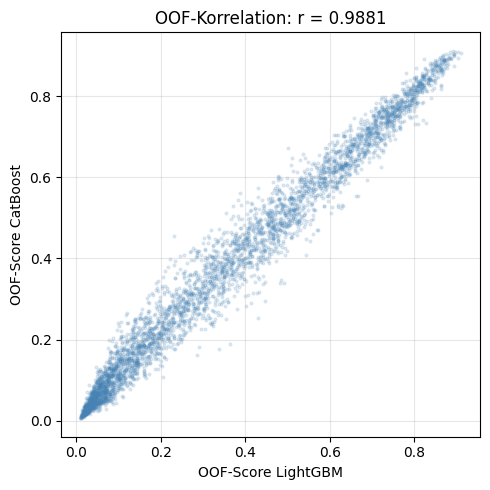

diversity_scatter.png gespeichert.


In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(oof_lgbm[::50], oof_catb[::50], alpha=0.15, s=4, color='steelblue')
ax.set_xlabel('OOF-Score LightGBM')
ax.set_ylabel('OOF-Score CatBoost')
ax.set_title(f'OOF-Korrelation: r = {corr:.4f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'diversity_scatter.png', dpi=130, bbox_inches='tight')
plt.show()
print('diversity_scatter.png gespeichert.')

## 5. Stacking

Drei Konfigurationen werden per 5-Fold CV-PR-AUC verglichen:

**(a)** Bestes getuntes Einzelmodell (Referenz aus §3).

**(b)** `StackingClassifier` mit **Per-Modell-FE**: Jeder Base-Learner
(LightGBM, CatBoost, MLP, LogReg) erhält seine eigene Pipeline —
`FunctionTransformer(build_enriched_features, kw_args=...)` →
ggf. `StandardScaler` → Modell. Meta-Learner: `LogisticRegression`.

**(c)** `StackingClassifier` mit **einheitlichem enriched30** für alle Base-Learner
(Kontrollvariante ohne Per-Modell-FE).

`cv=5` im `StackingClassifier` erzeugt leakagefreie OOF-Meta-Features (innere Schleife).
Der äußere `cross_val_score` mit denselben 5 Folds schätzt die generalisierte PR-AUC.
Hinweis: 5 × (5 × 4 Base-Learner) Fits → hohe Laufzeit; `n_jobs=1` vermeidet
Deadlocks durch verschachtelte Parallelisierung.

**Sparsamkeitsregel:** Stacking wird nur gewählt, wenn CV-PR-AUC > bestes
Einzelmodell + 0,001. Andernfalls: Einzelmodell (geringere Komplexität).

In [11]:
def _fe_kw_from_variant(variant):
    """FunctionTransformer kw_args for build_enriched_features from variant name."""
    _map = {
        'raw21':          None,  # identity — handled separately
        'enriched30':     {'bmi_encoding': 'raw',         'use_hurdle': True},
        'nohurdle26':     {'bmi_encoding': 'raw',         'use_hurdle': False},
        'bmi_capped':     {'bmi_encoding': 'capped',      'use_hurdle': True},
        'bmi_categorical':{'bmi_encoding': 'categorical', 'use_hurdle': True},
    }
    return _map[variant]


def _make_fe_step(variant):
    kw = _fe_kw_from_variant(variant)
    if kw is None:
        return ('fe', FunctionTransformer(func=None, validate=False))
    return ('fe', FunctionTransformer(build_enriched_features, kw_args=kw, validate=False))


def build_lgbm_pipe(params, variant, spw, seed):
    return Pipeline([
        _make_fe_step(variant),
        ('clf', LGBMClassifier(**params, scale_pos_weight=spw,
                               importance_type='gain', verbose=-1,
                               random_state=seed, n_jobs=-1)),
    ])


def build_mlp_pipe(params, variant, seed):
    # hidden_layer_sizes wird als String gespeichert (JSON-kompatibel) → hier konvertieren
    p = dict(params)
    if isinstance(p.get('hidden_layer_sizes'), str):
        p['hidden_layer_sizes'] = tuple(
            int(x) for x in p['hidden_layer_sizes'].strip('()').split(',') if x)
    return Pipeline([
        _make_fe_step(variant),
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(**p, early_stopping=True, random_state=seed)),
    ])


def build_logreg_pipe(params, variant, seed):
    return Pipeline([
        _make_fe_step(variant),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            penalty='elasticnet', l1_ratio=params['l1_ratio'], C=params['C'],
            solver='saga', class_weight='balanced',
            max_iter=5000, random_state=seed)),
    ])


def build_catboost_pipe(params, variant, spw, seed):
    return Pipeline([
        _make_fe_step(variant),
        ('clf', CatBoostClassifier(**params, scale_pos_weight=spw,
                                   verbose=0, random_state=seed)),
    ])


print('Pipeline-Factories definiert.')

Pipeline-Factories definiert.


In [12]:
lgbm_p  = tuning_results['LightGBM']['best_params']
mlp_p   = tuning_results['MLP']['best_params']
lr_p    = tuning_results['LogReg']['best_params']
cb_p    = tuning_results['CatBoost']['best_params']

lgbm_var = tuning_results['LightGBM']['variant']
mlp_var  = tuning_results['MLP']['variant']
lr_var   = tuning_results['LogReg']['variant']
cb_var   = tuning_results['CatBoost']['variant']

# --- (b) Per-Modell-FE Stacking ---
base_per_fe = [
    ('lgbm',     build_lgbm_pipe(lgbm_p, lgbm_var, spw, SEED)),
    ('mlp',      build_mlp_pipe(mlp_p,   mlp_var,       SEED)),
    ('logreg',   build_logreg_pipe(lr_p, lr_var,         SEED)),
    ('catboost', build_catboost_pipe(cb_p, cb_var, spw,  SEED)),
]

stacking_per_fe = StackingClassifier(
    estimators      = base_per_fe,
    final_estimator = LogisticRegression(max_iter=1000, random_state=SEED),
    cv              = 5,
    stack_method    = 'predict_proba',
    n_jobs          = 1,
)

# --- (c) Unified enriched30 Stacking ---
enr30_kw = {'bmi_encoding': 'raw', 'use_hurdle': True}
base_unified = [
    ('lgbm', Pipeline([
        ('fe',  FunctionTransformer(build_enriched_features, kw_args=enr30_kw, validate=False)),
        ('clf', LGBMClassifier(**lgbm_p, scale_pos_weight=spw,
                               importance_type='gain', verbose=-1,
                               random_state=SEED, n_jobs=-1)),
    ])),
    ('mlp', Pipeline([
        ('fe',     FunctionTransformer(build_enriched_features, kw_args=enr30_kw, validate=False)),
        ('scaler', StandardScaler()),
        ('clf',    MLPClassifier(
            **{k: (tuple(int(x) for x in v.strip('()').split(',') if x)
                   if k == 'hidden_layer_sizes' and isinstance(v, str) else v)
               for k, v in mlp_p.items()},
            early_stopping=True, random_state=SEED)),
    ])),
    ('logreg', Pipeline([
        ('fe',     FunctionTransformer(build_enriched_features, kw_args=enr30_kw, validate=False)),
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
            penalty='elasticnet', l1_ratio=lr_p['l1_ratio'], C=lr_p['C'],
            solver='saga', class_weight='balanced',
            max_iter=5000, random_state=SEED)),
    ])),
    ('catboost', Pipeline([
        ('fe',  FunctionTransformer(build_enriched_features, kw_args=enr30_kw, validate=False)),
        ('clf', CatBoostClassifier(**cb_p, scale_pos_weight=spw,
                                   verbose=0, random_state=SEED)),
    ])),
]

stacking_unified = StackingClassifier(
    estimators      = base_unified,
    final_estimator = LogisticRegression(max_iter=1000, random_state=SEED),
    cv              = 5,
    stack_method    = 'predict_proba',
    n_jobs          = 1,
)

print(f'Stacking (b) Base-Learner: {[n for n, _ in base_per_fe]}')
print(f'Stacking (c) Base-Learner: {[n for n, _ in base_unified]}')

Stacking (b) Base-Learner: ['lgbm', 'mlp', 'logreg', 'catboost']
Stacking (c) Base-Learner: ['lgbm', 'mlp', 'logreg', 'catboost']


In [13]:
print('(b) Stacking mit Per-Modell-FE — CV läuft...')
t0 = time.time()
scores_b = cross_val_score(stacking_per_fe, X_train, y_train,
                            cv=cv, scoring=SCORING, n_jobs=1)
prauc_b  = float(scores_b.mean())
std_b    = float(scores_b.std())
print(f'  PR-AUC = {prauc_b:.4f} ± {std_b:.4f}  ({time.time()-t0:.1f}s)')

print('\n(c) Stacking mit einheitlichem enriched30 — CV läuft...')
t0 = time.time()
scores_c = cross_val_score(stacking_unified, X_train, y_train,
                            cv=cv, scoring=SCORING, n_jobs=1)
prauc_c  = float(scores_c.mean())
std_c    = float(scores_c.std())
print(f'  PR-AUC = {prauc_c:.4f} ± {std_c:.4f}  ({time.time()-t0:.1f}s)')

(b) Stacking mit Per-Modell-FE — CV läuft...
  PR-AUC = 0.4359 ± 0.0068  (1325.2s)

(c) Stacking mit einheitlichem enriched30 — CV läuft...
  PR-AUC = 0.4333 ± 0.0067  (1565.7s)


In [14]:
SPARSAMKEIT_DELTA = 0.001  # Stacking muss Einzelmodell um mindestens diesen Wert schlagen

comparison = {
    f'(a) {best_single_name} (getunt)': best_single_prauc,
    '(b) Stacking Per-Modell-FE':       prauc_b,
    '(c) Stacking Unified enriched30':  prauc_c,
}

print('Konfigurationsvergleich:')
print(f'  {"Konfiguration":<40} | {"CV PR-AUC":>10} | {"vs. (a)":>8}')
print('  ' + '-' * 65)
for label, score in comparison.items():
    delta_vs_single = score - best_single_prauc
    print(f'  {label:<40} | {score:>10.4f} | {delta_vs_single:>+8.4f}')

print(f'\nSparsamkeitsregel: Stacking gewinnt nur bei Δ > {SPARSAMKEIT_DELTA}')

best_stacking = max(prauc_b, prauc_c)
if best_stacking > best_single_prauc + SPARSAMKEIT_DELTA:
    if prauc_b >= prauc_c:
        WINNER = 'stacking_per_fe'
        WINNER_PRAUC = prauc_b
        WINNER_LABEL = '(b) Stacking Per-Modell-FE'
    else:
        WINNER = 'stacking_unified'
        WINNER_PRAUC = prauc_c
        WINNER_LABEL = '(c) Stacking Unified enriched30'
else:
    WINNER = 'single'
    WINNER_PRAUC = best_single_prauc
    WINNER_LABEL = f'(a) {best_single_name} (getunt)'

print(f'\n>>> Finales Modell: {WINNER_LABEL}  →  CV PR-AUC = {WINNER_PRAUC:.4f} <<<')

Konfigurationsvergleich:
  Konfiguration                            |  CV PR-AUC |  vs. (a)
  -----------------------------------------------------------------
  (a) LightGBM (getunt)                    |     0.4359 |  +0.0000
  (b) Stacking Per-Modell-FE               |     0.4359 |  -0.0000
  (c) Stacking Unified enriched30          |     0.4333 |  -0.0026

Sparsamkeitsregel: Stacking gewinnt nur bei Δ > 0.001

>>> Finales Modell: (a) LightGBM (getunt)  →  CV PR-AUC = 0.4359 <<<


**Interpretation:** Stacking bringt Mehrwert, wenn die Base-Learner komplementäre
Fehler machen. Ist die OOF-Korrelation hoch (§4), sind die Fehler zu ähnlich —
das Ensemble mittelt dann redundante Vorhersagen. Per-Modell-FE erlaubt jedem
Base-Learner, seine stärkste Feature-Repräsentation zu nutzen, was theoretisch
die Dekorrelation der Fehler erhöht. Ob das in der Praxis gewinnt, entscheidet
die CV-Zahl.

## 6. Finales Modell + Export

Die Gewinner-Konfiguration wird auf dem **gesamten Trainingsset** gefittet.
Das finale Modell ist eine vollständige sklearn-Pipeline, die rohen `X_train`
(21 Features) als Input erwartet und FE intern anwendet — NB08 kann es direkt
mit `X_test` aufrufen, ohne separat FE anwenden zu müssen.

Gespeichert werden:
- `models/final_model.pkl` — gefittetes Pipeline-Objekt
- `outputs/07_modeling_opt/final_model_meta.json` — Architektur, Hyperparameter,
  CV-PR-AUC, Feature-Sets

**Kein Test-Touch.**

In [15]:
if WINNER == 'stacking_per_fe':
    final_model = StackingClassifier(
        estimators = [
            ('lgbm',     build_lgbm_pipe(lgbm_p, lgbm_var, spw, SEED)),
            ('mlp',      build_mlp_pipe(mlp_p,   mlp_var,       SEED)),
            ('logreg',   build_logreg_pipe(lr_p, lr_var,         SEED)),
            ('catboost', build_catboost_pipe(cb_p, cb_var, spw,  SEED)),
        ],
        final_estimator = LogisticRegression(max_iter=1000, random_state=SEED),
        cv              = 5,
        stack_method    = 'predict_proba',
        n_jobs          = 1,
    )
    meta = {
        'architecture': 'StackingClassifier (Per-Modell-FE)',
        'base_learners': {
            'lgbm':     {'variant': lgbm_var, 'params': lgbm_p},
            'mlp':      {'variant': mlp_var,  'params': mlp_p},
            'logreg':   {'variant': lr_var,   'params': lr_p},
            'catboost': {'variant': cb_var,   'params': cb_p},
        },
        'meta_learner': 'LogisticRegression',
    }

elif WINNER == 'stacking_unified':
    final_model = StackingClassifier(
        estimators = [
            ('lgbm', Pipeline([
                ('fe',  FunctionTransformer(build_enriched_features,
                                            kw_args=enr30_kw, validate=False)),
                ('clf', LGBMClassifier(**lgbm_p, scale_pos_weight=spw,
                                       importance_type='gain', verbose=-1,
                                       random_state=SEED, n_jobs=-1)),
            ])),
            ('mlp', Pipeline([
                ('fe',     FunctionTransformer(build_enriched_features,
                                               kw_args=enr30_kw, validate=False)),
                ('scaler', StandardScaler()),
                ('clf',    MLPClassifier(
                    **{k: (tuple(int(x) for x in v.strip('()').split(',') if x)
                           if k == 'hidden_layer_sizes' and isinstance(v, str) else v)
                       for k, v in mlp_p.items()},
                    early_stopping=True, random_state=SEED)),
            ])),
            ('logreg', Pipeline([
                ('fe',     FunctionTransformer(build_enriched_features,
                                               kw_args=enr30_kw, validate=False)),
                ('scaler', StandardScaler()),
                ('clf',    LogisticRegression(
                    penalty='elasticnet', l1_ratio=lr_p['l1_ratio'], C=lr_p['C'],
                    solver='saga', class_weight='balanced',
                    max_iter=5000, random_state=SEED)),
            ])),
            ('catboost', Pipeline([
                ('fe',  FunctionTransformer(build_enriched_features,
                                            kw_args=enr30_kw, validate=False)),
                ('clf', CatBoostClassifier(**cb_p, scale_pos_weight=spw,
                                           verbose=0, random_state=SEED)),
            ])),
        ],
        final_estimator = LogisticRegression(max_iter=1000, random_state=SEED),
        cv              = 5,
        stack_method    = 'predict_proba',
        n_jobs          = 1,
    )
    meta = {
        'architecture': 'StackingClassifier (Unified enriched30)',
        'base_learners': {
            'lgbm':     {'variant': 'enriched30', 'params': lgbm_p},
            'mlp':      {'variant': 'enriched30', 'params': mlp_p},
            'logreg':   {'variant': 'enriched30', 'params': lr_p},
            'catboost': {'variant': 'enriched30', 'params': cb_p},
        },
        'meta_learner': 'LogisticRegression',
    }

else:  # single model — wrap in FE pipeline for consistent inference interface
    winner_variant = tuning_results[best_single_name]['variant']
    fe_step = _make_fe_step(winner_variant)
    if best_single_name == 'LightGBM':
        final_model = Pipeline([
            fe_step,
            ('clf', LGBMClassifier(**lgbm_p, scale_pos_weight=spw,
                                   importance_type='gain', verbose=-1,
                                   random_state=SEED, n_jobs=-1)),
        ])
    elif best_single_name == 'MLP':
        final_model = Pipeline([
            fe_step,
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(
                **{k: (tuple(int(x) for x in v.strip('()').split(',') if x)
                       if k == 'hidden_layer_sizes' and isinstance(v, str) else v)
                   for k, v in mlp_p.items()},
                early_stopping=True, random_state=SEED)),
        ])
    elif best_single_name == 'LogReg':
        final_model = Pipeline([
            fe_step,
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                penalty='elasticnet', l1_ratio=lr_p['l1_ratio'], C=lr_p['C'],
                solver='saga', class_weight='balanced',
                max_iter=5000, random_state=SEED)),
        ])
    else:  # CatBoost
        final_model = Pipeline([
            fe_step,
            ('clf', CatBoostClassifier(**cb_p, scale_pos_weight=spw,
                                       verbose=0, random_state=SEED)),
        ])
    meta = {
        'architecture': f'Single: {best_single_name}',
        'variant':      winner_variant,
        'params':       tuning_results[best_single_name]['best_params'],
    }

print(f'Finales Modell: {WINNER_LABEL}')
print('Wird auf gesamtem Trainingsset gefittet...')
t0 = time.time()
final_model.fit(X_train, y_train)
print(f'Fit abgeschlossen ({time.time()-t0:.1f}s).')

Finales Modell: (a) LightGBM (getunt)
Wird auf gesamtem Trainingsset gefittet...
Fit abgeschlossen (16.9s).


In [16]:
joblib.dump(final_model, MODELS_DIR / 'final_model.pkl')
print(f'final_model.pkl gespeichert: {(MODELS_DIR / "final_model.pkl").resolve()}')

meta['cv_prauc']       = WINNER_PRAUC
meta['winner_label']   = WINNER_LABEL
meta['diversity_corr'] = round(corr, 4)
meta['seed']           = SEED

with open(OUTPUTS_DIR / 'final_model_meta.json', 'w') as _f:
    json.dump(meta, _f, indent=2)
print('final_model_meta.json gespeichert.')

expected = [
    MODELS_DIR  / 'final_model.pkl',
    OUTPUTS_DIR / 'fe_ablation.csv',
    OUTPUTS_DIR / 'tuning_results.json',
    OUTPUTS_DIR / 'diversity_check.json',
    OUTPUTS_DIR / 'diversity_scatter.png',
    OUTPUTS_DIR / 'final_model_meta.json',
]
print('\nExport-Check:')
all_ok = True
for p in expected:
    ok = p.exists()
    print(f'  {"OK" if ok else "FEHLT":>5}  {p}')
    all_ok = all_ok and ok
print(f'\nAlle Outputs vorhanden: {all_ok}')

final_model.pkl gespeichert: C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\models\final_model.pkl
final_model_meta.json gespeichert.

Export-Check:
     OK  ..\models\final_model.pkl
     OK  ..\outputs\07_modeling_opt\fe_ablation.csv
     OK  ..\outputs\07_modeling_opt\tuning_results.json
     OK  ..\outputs\07_modeling_opt\diversity_check.json
     OK  ..\outputs\07_modeling_opt\diversity_scatter.png
     OK  ..\outputs\07_modeling_opt\final_model_meta.json

Alle Outputs vorhanden: True


## 7. Abschluss-Report

Tabellarische Übersicht aller Optimierungsstufen — von NB06-Default bis finales
Modell. Zeigt den kumulierten Gewinn pro Schritt.

In [17]:
nb06_default = 0.4327  # LightGBM Default auf Enriched 30, NB06 Sektion 8

report_rows = []

report_rows.append({
    'Stufe': '1 — NB06 Default (LightGBM, enriched30)',
    'CV PR-AUC': nb06_default,
    'Δ vs. vorherige Stufe': '',
    'Anmerkung': 'Referenz aus NB06 Sektion 8',
})

prev = nb06_default
for m in ['LightGBM', 'MLP', 'LogReg', 'CatBoost']:
    info = best_feat_per_model[m]
    delta = round(info['prauc'] - prev, 4) if m == 'LightGBM' else ''
    report_rows.append({
        'Stufe': f'2 — Beste FE-Variante {m} ({info["variant"]})',
        'CV PR-AUC': info['prauc'],
        'Δ vs. vorherige Stufe': delta,
        'Anmerkung': 'Per-Modell FE-Ablation',
    })

lgbm_tuned = tuning_results['LightGBM']['tuned_prauc']
report_rows.append({
    'Stufe': '3 — Getunt LightGBM (Optuna)',
    'CV PR-AUC': lgbm_tuned,
    'Δ vs. vorherige Stufe': round(lgbm_tuned - best_feat_per_model['LightGBM']['prauc'], 4),
    'Anmerkung': f'{N_TRIALS} Trials',
})
report_rows.append({
    'Stufe': f'3 — Bestes getuntes Einzelmodell ({best_single_name})',
    'CV PR-AUC': best_single_prauc,
    'Δ vs. vorherige Stufe': round(best_single_prauc - lgbm_tuned, 4),
    'Anmerkung': 'Maximales Einzelmodell nach Tuning',
})
report_rows.append({
    'Stufe': '5 — Stacking Per-Modell-FE',
    'CV PR-AUC': round(prauc_b, 4),
    'Δ vs. vorherige Stufe': round(prauc_b - best_single_prauc, 4),
    'Anmerkung': 'vs. bestes Einzelmodell',
})
report_rows.append({
    'Stufe': '5 — Stacking Unified enriched30',
    'CV PR-AUC': round(prauc_c, 4),
    'Δ vs. vorherige Stufe': round(prauc_c - best_single_prauc, 4),
    'Anmerkung': 'Kontrollvariante',
})

df_report = pd.DataFrame(report_rows)
print('=== Abschluss-Report NB07 ===')
for _, row in df_report.iterrows():
    delta_str = f'(Δ {row["Δ vs. vorherige Stufe"]:+.4f})' if row['Δ vs. vorherige Stufe'] != '' else ''
    print(f'  {str(row["CV PR-AUC"]):>6}  {delta_str:<16}  {row["Stufe"]}')

df_report.to_csv(OUTPUTS_DIR / 'abschluss_report.csv', index=False)

print(f'\n>>> Finales Modell für NB08: {WINNER_LABEL}')
print(f'    CV PR-AUC (5-Fold): {WINNER_PRAUC:.4f}')
print(f'    Datei: {(MODELS_DIR / "final_model.pkl").resolve()}')

print('\nOffen für NB08:')
print('  - Test-Evaluation: final_model.predict_proba(X_test) → PR-AUC, ROC-AUC')
print('  - Threshold-Optimierung: Recall-Constraint ≥ 0.80 (NB01 Cost-Matrix)')
print('  - Kalibrierung: Brier-Score, Calibration Plot, ggf. Platt/Isotonic')
print('  - Fairness: Subgruppen-PR-AUC nach Geschlecht, Alter, Einkommen')
print('  - SHAP: globale + lokale Erklärbarkeit')

=== Abschluss-Report NB07 ===
  0.4327                    1 — NB06 Default (LightGBM, enriched30)
  0.4353  (Δ +0.0026)       2 — Beste FE-Variante LightGBM (raw21)
  0.4324                    2 — Beste FE-Variante MLP (raw21)
  0.4216                    2 — Beste FE-Variante LogReg (bmi_capped)
  0.4303                    2 — Beste FE-Variante CatBoost (raw21)
  0.4359  (Δ +0.0006)       3 — Getunt LightGBM (Optuna)
  0.4359  (Δ +0.0000)       3 — Bestes getuntes Einzelmodell (LightGBM)
  0.4359  (Δ -0.0000)       5 — Stacking Per-Modell-FE
  0.4333  (Δ -0.0026)       5 — Stacking Unified enriched30

>>> Finales Modell für NB08: (a) LightGBM (getunt)
    CV PR-AUC (5-Fold): 0.4359
    Datei: C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\models\final_model.pkl

Offen für NB08:
  - Test-Evaluation: final_model.predict_proba(X_test) → PR-AUC, ROC-AUC
  - Threshold-Optimierung: Recall-Constraint ≥ 0.80 (NB01 Cost-Matrix)
  - Kalibrierung: Brier-Score, Calibration Plot, ggf. Platt/Is